# Import libraries

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from googleapiclient.discovery import build
from transformers import pipeline
from dotenv import load_dotenv
from datetime import datetime, timezone
from dateutil.relativedelta import relativedelta
from atproto import Client
import time
from langdetect import detect, LangDetectException
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import re
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import umap

/home/andre/telecom/aibubble/ai-bubble/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Check what is the predominant emotion inside a cluster

In [36]:
df = pd.read_csv("bluesky_ai_posts_with_clusters.csv")

In [11]:
print("Loading emotion analysis model (this might take a moment)...")
emotion_classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")
print("Model loaded successfully!")

Loading emotion analysis model (this might take a moment)...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 24902.57it/s]


Model loaded successfully!


In [12]:
# For each cluster, analyze emotions and  consider only the predictions with confidence > 0.5
emotion_results = []
for cluster in sorted(df["cluster"].unique()):
    cluster_posts = df[df["cluster"] == cluster]["Text"].tolist()
    for post in cluster_posts:
        emotion = emotion_classifier(post)[0]
        emotion_results.append({
            "cluster": cluster,
            "post": post,
            "emotion": emotion["label"],
            "confidence": emotion["score"]
        })

In [13]:
df["emotion"] = [result["emotion"] for result in emotion_results]
df["emotion_confidence"] = [result["confidence"] for result in emotion_results]
#save results to csv
df.to_csv("bluesky_ai_posts_with_emotions.csv", index=False)

In [9]:
# Print emotion results per cluster
for cluster in sorted(df["cluster"].unique()):
    cluster_emotions = [res for res in emotion_results if res["cluster"] == cluster]
    print(f"\nCluster {cluster} - Emotion Distribution:")
    emotion_counts = pd.Series([res["emotion"] for res in cluster_emotions]).value_counts()
    print(emotion_counts)


Cluster -1 - Emotion Distribution:
neutral     322
fear        313
joy          62
anger        56
surprise     38
sadness      18
disgust      17
Name: count, dtype: int64

Cluster 0 - Emotion Distribution:
neutral     1019
fear         259
surprise     166
joy          112
anger        100
disgust       80
sadness       59
Name: count, dtype: int64

Cluster 1 - Emotion Distribution:
neutral     2729
fear        1307
joy          377
surprise     364
anger        353
disgust      288
sadness      165
Name: count, dtype: int64


# Check mediatic fear and financial fear relationship

In [1]:
# AI FEAR
df = pd.read_csv("bluesky_ai_posts_with_emotions.csv")

df["Date"] = pd.to_datetime(
    df["Date"],
    format="mixed",
    utc=True
).dt.normalize()

AI_fear = df[
    (df["emotion"] == "fear") &
    (df["emotion_confidence"] > 0.5)
]

NameError: name 'pd' is not defined

In [ ]:
daily_total = (
    df.groupby(df["Date"])["emotion_confidence"]
      .sum()
      .rename("total_posts")
)

daily_fear = (
    AI_fear.groupby(AI_fear["Date"])["emotion_confidence"]
           .sum()
           .rename("fear_posts")
)

fear_index = pd.concat(
    [daily_total, daily_fear],
    axis=1
).fillna(0)

fear_index["fear_ratio"] = (
    fear_index["fear_posts"] /
    fear_index["total_posts"]
)

In [ ]:
fear_index["fear_ratio"].describe()

count    1386.000000
mean        0.196222
std         0.218464
min         0.000000
25%         0.000000
50%         0.142857
75%         0.300000
max         1.000000
Name: fear_ratio, dtype: float64

In [ ]:
fear_index["total_posts"].describe()

count    1386.000000
mean        7.322511
std         6.725716
min         1.000000
25%         3.000000
50%         6.000000
75%        10.000000
max        83.000000
Name: total_posts, dtype: float64

<Axes: xlabel='Date'>

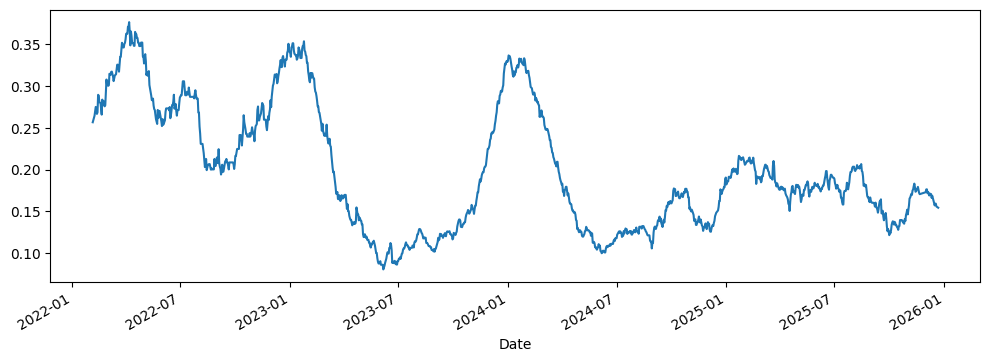

In [ ]:
fear_index["fear_ratio_60"] = (
    fear_index["fear_ratio"]
    .rolling(60, min_periods=30)
    .mean()
)

fear_index["fear_ratio_60"].plot(figsize=(12,4))

In [ ]:
fear_index["fear_ratio_60"].autocorr(lag=30)

np.float64(0.8321024349901087)

In [ ]:
fear_index["fear_ratio_60"].autocorr(lag=60)

np.float64(0.5391228100009527)

In [ ]:
##### financial fear
import yfinance as yf

vix = yf.download("^VIX", start="2022-01-01", end="2025-12-12")

vix.columns = vix.columns.get_level_values(0)
vix.index = pd.to_datetime(vix.index).normalize()

vix["VIX_60"] = (
    vix["Close"]
    .rolling(60, min_periods=30)
    .mean()
)



fear = fear_index[["fear_ratio_60"]].copy()
fear.index = pd.to_datetime(fear.index, utc=True).tz_convert(None).normalize()

vix2 = vix[["VIX_60"]].copy()
vix2.index = pd.to_datetime(vix2.index, utc=True).tz_convert(None).normalize()

combined = fear.join(vix2, how="inner").dropna()

combined.dropna(inplace=True)


[*********************100%***********************]  1 of 1 completed


In [ ]:
combined.corr()

,fear_ratio_60,VIX_60
fear_ratio_60,1.000000,0.548933
VIX_60,0.548933,1.000000


<Axes: xlabel='Date'>

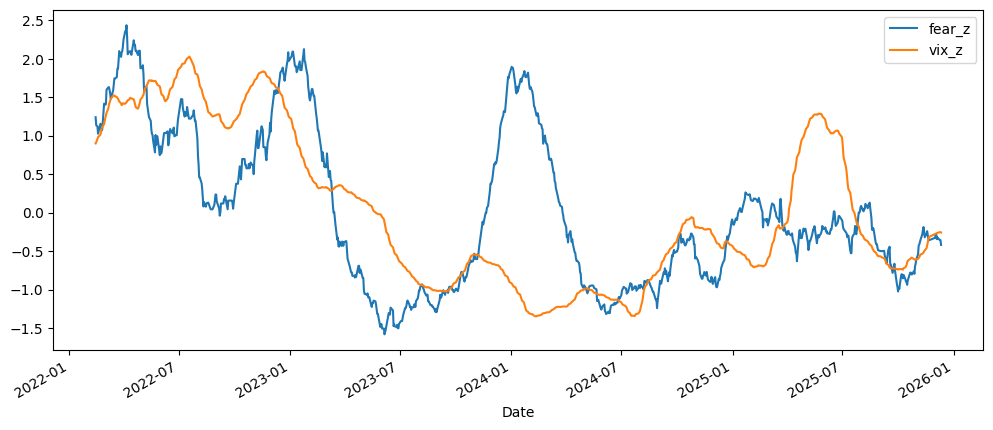

In [ ]:
combined_z = combined.copy()

combined_z["fear_z"] = (
    combined_z["fear_ratio_60"] - combined_z["fear_ratio_60"].mean()
) / combined_z["fear_ratio_60"].std()

combined_z["vix_z"] = (
    combined_z["VIX_60"] - combined_z["VIX_60"].mean()
) / combined_z["VIX_60"].std()

combined_z[["fear_z", "vix_z"]].plot(figsize=(12,5))

<Axes: >

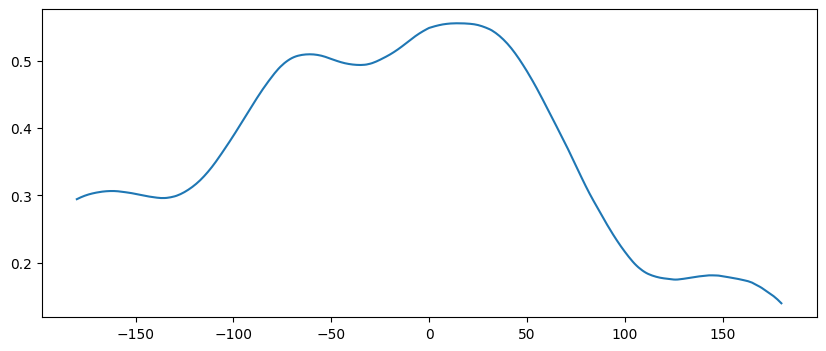

In [ ]:
lags = range(-180,181)

corrs = []

for lag in lags:
    corrs.append(
        combined_z["fear_z"].corr(
            combined_z["vix_z"].shift(lag)
        )
    )

lag_corr = pd.Series(corrs, index=lags)

lag_corr.plot(figsize=(10,4))

In [ ]:
lag_corr.idxmax(), lag_corr.max()

(14, np.float64(0.5558530388231903))

In [ ]:
test = combined.copy()

test["fear_change"] = test["fear_ratio_60"].diff()
test["vix_change"] = test["VIX_60"].diff()

test = test.dropna()

<Axes: >

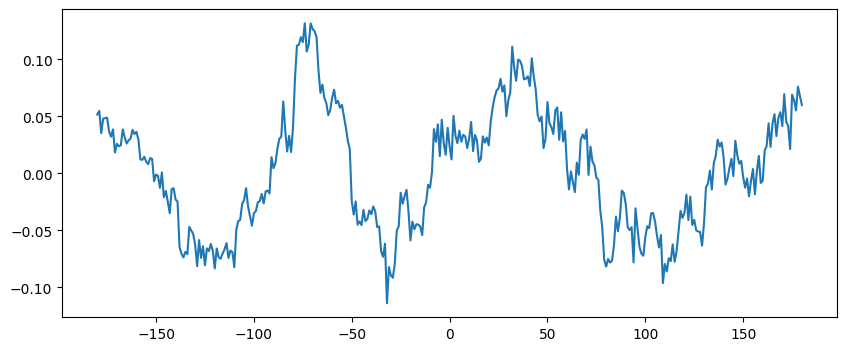

In [ ]:
lags = range(-180,181)

corrs = []

for lag in lags:
    corrs.append(
        test["fear_change"].corr(
            test["vix_change"].shift(lag)
        )
    )

lag_corr = pd.Series(corrs, index=lags)

lag_corr.plot(figsize=(10,4))

In [ ]:
lag_corr.idxmax(), lag_corr.max()

(-74, np.float64(0.1317780695521224))

# Testing with AI assets

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd

tickers = ["NVDA", "THNQ", "AIQ"]

# download
data = {}

for ticker in tickers:
    asset = yf.download(
        ticker,
        start="2022-01-01",
        end="2025-12-12",
        auto_adjust=True
    )

    asset.columns = asset.columns.get_level_values(0)

    asset.index = pd.to_datetime(asset.index, utc=True).tz_convert(None).normalize()

    asset["return"] = np.log(asset["Close"] / asset["Close"].shift(1))

    asset[f"{ticker}_vol60"] = (
        asset["return"]
        .rolling(60, min_periods=30)
        .std()
        * np.sqrt(252)
    )

    data[ticker] = asset[[f"{ticker}_vol60"]]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
fear = fear_index["fear_ratio_60"].copy()
fear.index = pd.to_datetime(fear.index, utc=True).tz_convert(None).normalize()
fear.name = "AIFear"

In [ ]:
combined_assets = pd.concat(
    [fear, data["NVDA"], data["THNQ"], data["AIQ"]],
    axis=1
).dropna()

/tmp/ipykernel_31553/3917068606.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined_assets = pd.concat(


In [ ]:
combined_assets.head()
combined_assets.corr()["AIFear"]

AIFear        1.000000
NVDA_vol60    0.215052
THNQ_vol60    0.575953
AIQ_vol60     0.517923
Name: AIFear, dtype: float64

<Axes: >

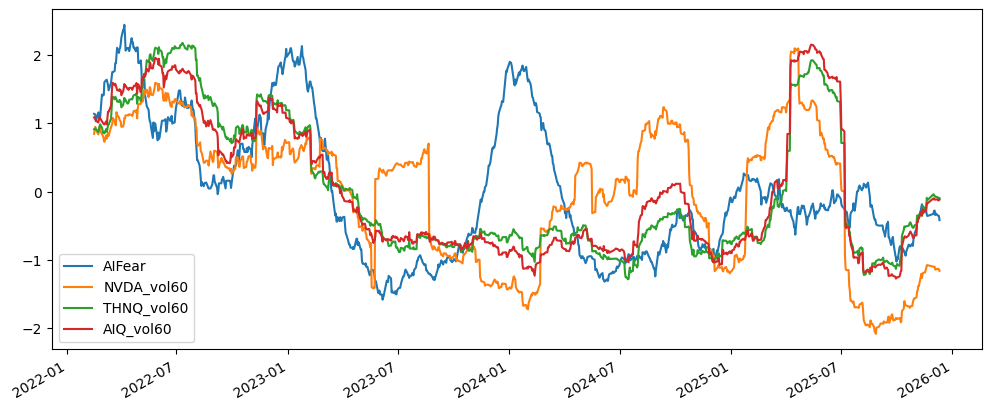

In [ ]:
combined_z = (
    combined_assets - combined_assets.mean()
) / combined_assets.std()

combined_z.plot(figsize=(12,5))

In [ ]:
lags = range(-180,181)

corrs = []
for metric in ["NVDA_vol60", "THNQ_vol60", "AIQ_vol60"]:
    lags = range(-180,181)
    corrs = []
    for lag in lags:
            corrs.append(
                combined_z["AIFear"].corr(
                    combined_z[metric].shift(lag)
                )
            )

    lag_corr = pd.Series(corrs, index=lags)

    print(
        metric,
        lag_corr.idxmax(),
        lag_corr.max()
    )

NVDA_vol60 132 0.363300825886158
THNQ_vol60 -3 0.5763249662114621
AIQ_vol60 0 0.5179234743236203


AIQ_vol60 -71 0.14980758024000335


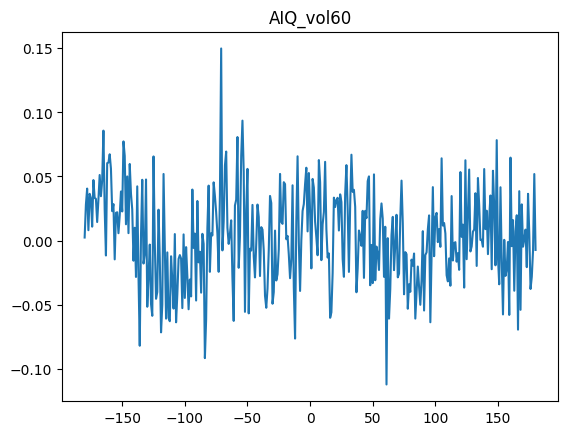

THNQ_vol60 -71 0.15933971742923303


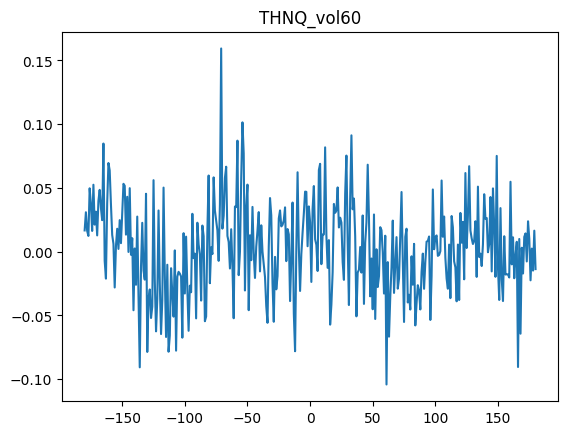

In [ ]:
lags = range(-180,181)

dFear = combined_z["AIFear"].diff().dropna()
dAIQ  = combined_z["AIQ_vol60"].diff().dropna()
dTHNQ = combined_z["THNQ_vol60"].diff().dropna()

corrs = []
for metric in [dAIQ, dTHNQ]:
    lags = range(-180,181)
    corrs = []
    for lag in lags:
            corrs.append(
                dFear.corr(
                   metric.shift(lag)
                )
            )

    lag_corr = pd.Series(corrs, index=lags)

    print(
        metric.name,
        lag_corr.idxmax(),
        lag_corr.max()
    )
    lag_corr.plot(title=metric.name)
    plt.show()